# HOUSE PRICES PRDICATION

# Business Problem

Description
Real estate companies and buyers often need to determine the estimated price of a house. Estimating prices manually is difficult because numerous factors (such as Area, Bedrooms, City, House Age, etc.) affect the price.

# Objective
To develop a Linear Regression Model that predicts the expected selling price of a house based on its characteristics.

# Target Variable
Target_Column (House Price)

# Independent Features
Area_sqft

Bedrooms

Bathrooms

City

Property_Type

House_Age

Garage_Capacity

School_Rating

Crime_Rate

Distance_to_City

Environment Setup and Data Loading

In [1]:
#Data manipulation
import pandas as pd
import numpy as np

# Data Visulization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning & Preprocessing

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Machine Learning Model
from sklearn.linear_model import LinearRegression

# Model Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

The required libraries for data manipulation, data visualization, data preprocessing, machine learning, and model evaluation were imported successfully.

The house_price_dataset.csv dataset was loaded into a DataFrame named data for further analysis and preprocessing.

In [2]:
data=pd.read_csv("house_price_dataset.csv")
data

,Record_ID,Sale_Date,City,Neighborhood,Property_Type,Bedrooms,Bathrooms,Area_sqft,Lot_Size,Floors,House_Age,Garage_Capacity,Distance_to_City,Crime_Rate,School_Rating,Has_Garden,Has_Pool,Condition,Heating_Type,Target_Column
0,1,2024-07-22,Thane,Thane,Independent House,2,1,1428.0,1849.7,1,14,0,24.0,1.3,2.3,True,True,Poor,Gas,14114722.44
1,2,2025-09-10,Nashik,Nashik,Apartment,1,1,1116.7,1760.2,1,27,1,38.3,4.0,2.3,True,False,Poor,Solar,10167899.87
2,3,2024-08-26,Mumbai,Mumbai,Villa,3,4,2300.1,5200.8,3,18,2,23.5,7.3,2.1,True,False,Fair,Electric,22519584.74
3,4,2024-10-03,Nagpur,Nagpur,Independent House,2,2,1186.5,2418.4,3,13,0,24.8,2.5,4.2,True,False,Good,Solar,11615354.08
4,5,2025-02-09,Nagpur,Nagpur,Independent House,1,1,1115.2,2483.7,2,2,2,3.6,9.2,3.7,False,True,Poor,Gas,11339279.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2025-03-13,Nashik,NaN,Independent House,4,4,2420.7,NaN,1,32,3,14.5,NaN,NaN,False,False,Good,NaN,23567882.25
996,997,2024-05-06,Thane,Thane,Villa,4,5,2053.4,2883.8,3,39,0,1.6,7.2,4.3,False,True,Fair,Solar,20333590.89
997,998,2025-08-15,Nagpur,Nagpur,Villa,3,4,1417.0,3519.0,3,27,1,35.5,7.9,3.8,False,False,Excellent,Electric,13138678.24
998,999,2025-04-05,Thane,Thane,Apartment,3,3,1904.0,2191.5,1,14,3,28.7,2.6,2.4,True,True,Good,Solar,18665588.95


# Initial Data Profiling

First, I checked the entire dataset using the `head()` and `tail()` functions.

In [3]:
data.head()

,Record_ID,Sale_Date,City,Neighborhood,Property_Type,Bedrooms,Bathrooms,Area_sqft,Lot_Size,Floors,House_Age,Garage_Capacity,Distance_to_City,Crime_Rate,School_Rating,Has_Garden,Has_Pool,Condition,Heating_Type,Target_Column
0,1,2024-07-22,Thane,Thane,Independent House,2,1,1428.0,1849.7,1,14,0,24.0,1.3,2.3,True,True,Poor,Gas,14114722.44
1,2,2025-09-10,Nashik,Nashik,Apartment,1,1,1116.7,1760.2,1,27,1,38.3,4.0,2.3,True,False,Poor,Solar,10167899.87
2,3,2024-08-26,Mumbai,Mumbai,Villa,3,4,2300.1,5200.8,3,18,2,23.5,7.3,2.1,True,False,Fair,Electric,22519584.74
3,4,2024-10-03,Nagpur,Nagpur,Independent House,2,2,1186.5,2418.4,3,13,0,24.8,2.5,4.2,True,False,Good,Solar,11615354.08
4,5,2025-02-09,Nagpur,Nagpur,Independent House,1,1,1115.2,2483.7,2,2,2,3.6,9.2,3.7,False,True,Poor,Gas,11339279.90


In [4]:
data.tail()

,Record_ID,Sale_Date,City,Neighborhood,Property_Type,Bedrooms,Bathrooms,Area_sqft,Lot_Size,Floors,House_Age,Garage_Capacity,Distance_to_City,Crime_Rate,School_Rating,Has_Garden,Has_Pool,Condition,Heating_Type,Target_Column
995,996,2025-03-13,Nashik,NaN,Independent House,4,4,2420.7,NaN,1,32,3,14.5,NaN,NaN,False,False,Good,NaN,23567882.25
996,997,2024-05-06,Thane,Thane,Villa,4,5,2053.4,2883.8,3,39,0,1.6,7.2,4.3,False,True,Fair,Solar,20333590.89
997,998,2025-08-15,Nagpur,Nagpur,Villa,3,4,1417.0,3519.0,3,27,1,35.5,7.9,3.8,False,False,Excellent,Electric,13138678.24
998,999,2025-04-05,Thane,Thane,Apartment,3,3,1904.0,2191.5,1,14,3,28.7,2.6,2.4,True,True,Good,Solar,18665588.95
999,1000,2024-05-29,Pune,Pune,Apartment,2,3,1575.2,2835.3,2,35,1,37.8,6.1,5.0,True,True,Excellent,Gas,15303355.67


I checked the shape of the dataset and found that it contains 1,000 rows and 20 columns.

In [5]:
# Checking dataset Shape
data.shape

(1000, 20)

The data types of all columns were checked using the dtypes attribute. The dataset contains integer (int64), floating-point (float64), string (str), and boolean (bool) data types.

In [6]:
# Checking all dataset types
data.dtypes

Record_ID             int64
Sale_Date               str
City                    str
Neighborhood            str
Property_Type           str
Bedrooms              int64
Bathrooms             int64
Area_sqft           float64
Lot_Size            float64
Floors                int64
House_Age             int64
Garage_Capacity       int64
Distance_to_City    float64
Crime_Rate          float64
School_Rating       float64
Has_Garden             bool
Has_Pool               bool
Condition               str
Heating_Type            str
Target_Column       float64
dtype: object

In [7]:
# Dataset Information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         1000 non-null   int64  
 1   Sale_Date         1000 non-null   str    
 2   City              1000 non-null   str    
 3   Neighborhood      950 non-null    str    
 4   Property_Type     1000 non-null   str    
 5   Bedrooms          1000 non-null   int64  
 6   Bathrooms         1000 non-null   int64  
 7   Area_sqft         1000 non-null   float64
 8   Lot_Size          950 non-null    float64
 9   Floors            1000 non-null   int64  
 10  House_Age         1000 non-null   int64  
 11  Garage_Capacity   1000 non-null   int64  
 12  Distance_to_City  1000 non-null   float64
 13  Crime_Rate        950 non-null    float64
 14  School_Rating     950 non-null    float64
 15  Has_Garden        1000 non-null   bool   
 16  Has_Pool          1000 non-null   bool   
 17  Conditi

The first five rows were displayed using head().
The last five rows were displayed using tail().
The dataset contains 1,000 rows and 20 columns.
The data types of all columns were checked using dtypes.
The dataset information was checked using info().
Some columns contain missing values (50 missing values each).

In [8]:
#checking total missing value
data.isnull().sum()

Record_ID            0
Sale_Date            0
City                 0
Neighborhood        50
Property_Type        0
Bedrooms             0
Bathrooms            0
Area_sqft            0
Lot_Size            50
Floors               0
House_Age            0
Garage_Capacity      0
Distance_to_City     0
Crime_Rate          50
School_Rating       50
Has_Garden           0
Has_Pool             0
Condition            0
Heating_Type        50
Target_Column        0
dtype: int64

Missing values were checked using isnull().sum(). The columns Neighborhood, Lot_Size, Crime_Rate, School_Rating, and Heating_Type each contain 50 missing values, while the remaining columns have no missing values.

In [9]:
#checking total missing value percentage
(data.isnull().sum() / len(data)) * 100

Record_ID           0.0
Sale_Date           0.0
City                0.0
Neighborhood        5.0
Property_Type       0.0
Bedrooms            0.0
Bathrooms           0.0
Area_sqft           0.0
Lot_Size            5.0
Floors              0.0
House_Age           0.0
Garage_Capacity     0.0
Distance_to_City    0.0
Crime_Rate          5.0
School_Rating       5.0
Has_Garden          0.0
Has_Pool            0.0
Condition           0.0
Heating_Type        5.0
Target_Column       0.0
dtype: float64

The percentage of missing values was calculated. The Neighborhood, Lot_Size, Crime_Rate, School_Rating, and Heating_Type columns each have 5% missing values, while all other columns have 0% missing values.

In [10]:
#stastical summary
data.describe()

,Record_ID,Bedrooms,Bathrooms,Area_sqft,Lot_Size,Floors,House_Age,Garage_Capacity,Distance_to_City,Crime_Rate,School_Rating,Target_Column
count,1000.000000,1000.000000,1000.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000,950.000000,950.000000,1.000000e+03
mean,500.500000,2.556000,2.605000,1490.634300,2691.697368,2.046000,19.915000,1.476000,20.396400,5.584526,3.510211,1.467087e+07
std,288.819436,1.210921,1.358978,524.964539,1149.299138,0.823749,11.931057,1.113851,11.243186,2.655714,0.881654,5.201402e+06
min,1.000000,1.000000,1.000000,300.000000,413.700000,1.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.992841e+06
25%,250.750000,2.000000,1.000000,1114.075000,1849.750000,1.000000,9.000000,0.000000,10.675000,3.100000,2.700000,1.094176e+07
50%,500.500000,3.000000,2.000000,1498.800000,2554.800000,2.000000,20.000000,1.000000,19.900000,5.600000,3.400000,1.470863e+07
75%,750.250000,3.000000,4.000000,1848.625000,3425.925000,3.000000,30.000000,2.000000,29.800000,7.900000,4.300000,1.813702e+07
max,1000.000000,7.000000,8.000000,3224.500000,7351.500000,3.000000,40.000000,3.000000,39.900000,10.000000,5.000000,3.251560e+07


The statistical summary of the numerical columns was generated using the describe() method.

# Exploratory Data Analysis (EDA)

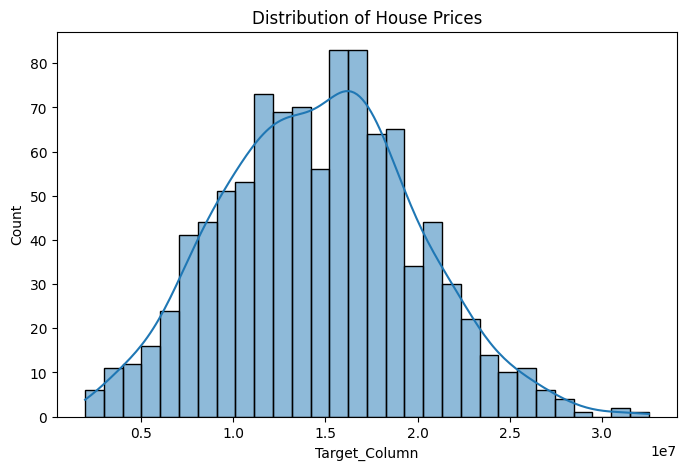

In [11]:
#Histogram
plt.figure(figsize=(8,5))
sns.histplot(data["Target_Column"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

The house prices range from approximately 2 million to 32 million.
The highest frequency is around 15–18 million.
The lowest frequency is below 5 million and above 28 million.
This indicates that most houses are priced in the 15–18 million range.

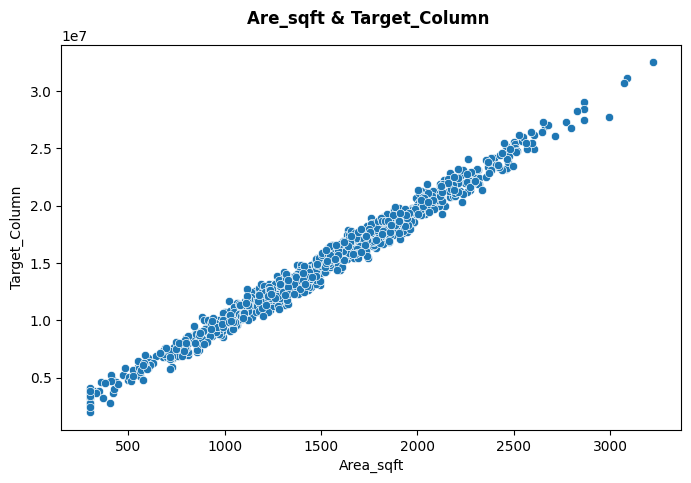

In [12]:
#scatter plot

plt.figure(figsize=(8,5))

sns.scatterplot(x="Area_sqft",y="Target_Column",data=data)



plt.title("Are_sqft & Target_Column ",fontweight="bold",pad=15)
plt.show()

The house area ranges from approximately 350 sq.ft to 3,250 sq.ft.
The house prices range from about 2 million to 32 million.
As the house area increases, the house price also increases.
This shows a strong positive linear relationship between area and price.

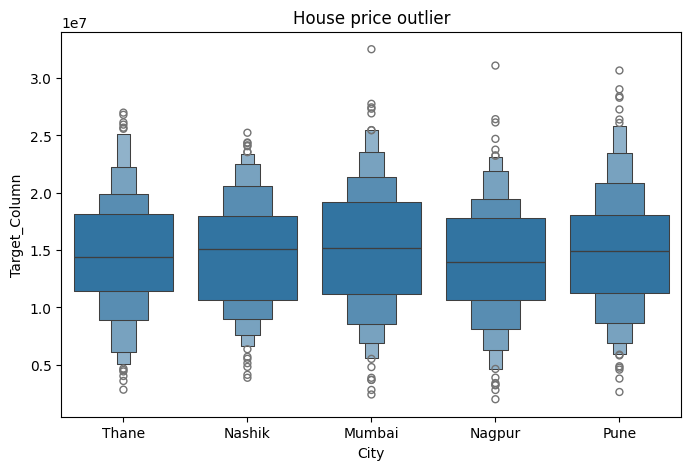

In [13]:
#Box plot
plt.figure(figsize=(8,5))

sns.boxenplot(x="City",y="Target_Column",data=data)

plt.title("House price outlier")

plt.show()



The median house price is approximately 15 million.
Most house prices lie between 10 million and 20 million.
A few outliers are present below 5 million and above 28 million.
The number of outliers is small compared to the total data. 

<function matplotlib.pyplot.show(close=None, block=None)>

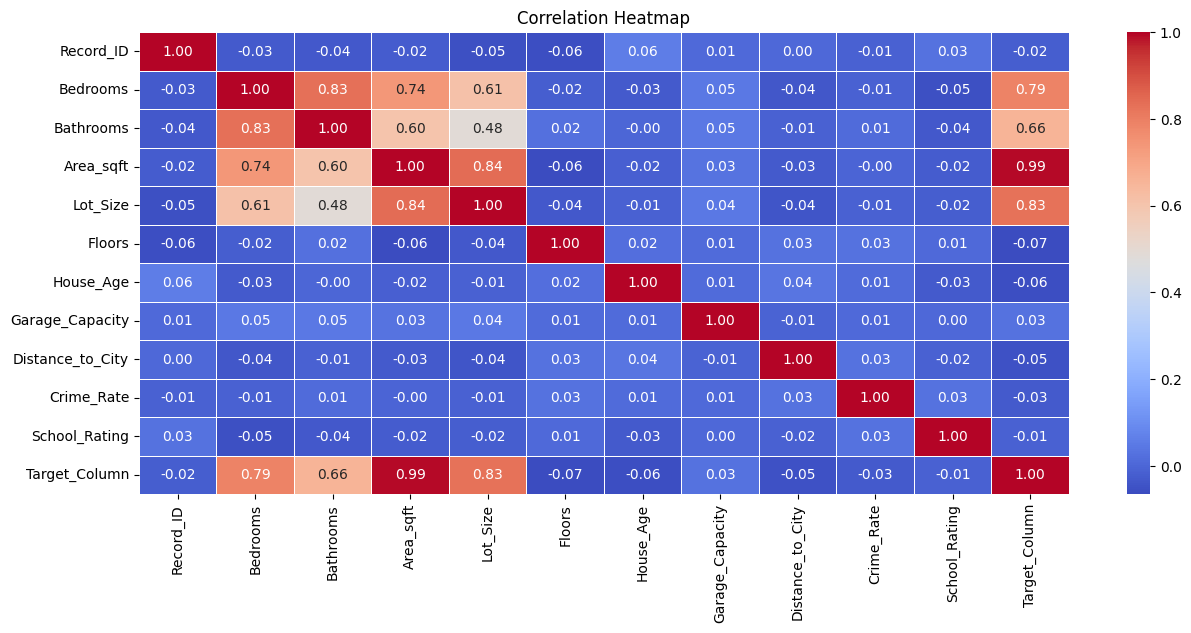

In [14]:
# correlation Heatmap
plt.figure(figsize=(15, 6))
nominal_cols = data.select_dtypes(include=[np.number]).columns
correlation_matrix = data[nominal_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show

Highest Positive Correlation: Area_sqft and Bedrooms have the highest positive correlation (0.74).

Highest Negative Correlation: Distance_to_City and House_Age have a slight negative correlation (-0.06 to -0.07 range across property features).

Target Correlations: Target_Column (Selling Price) is strongly positively correlated with Area_sqft (0.99) and Lot_Size (0.83).

Weak Correlations: Most other features (such as Crime_Rate, School_Rating, Garage_Capacity, and Record_ID) show weak correlations, with values close to 0.

# Data Cleaning and Feature Engineering

In [15]:
#Drop Column
data.drop("Sale_Date", axis=1, inplace=True)
data.drop("Record_ID", axis=1, inplace=True)

Sale_Date and Record_ID Column both drop in dataset

In [16]:
data=data.drop_duplicates()
data

,City,Neighborhood,Property_Type,Bedrooms,Bathrooms,Area_sqft,Lot_Size,Floors,House_Age,Garage_Capacity,Distance_to_City,Crime_Rate,School_Rating,Has_Garden,Has_Pool,Condition,Heating_Type,Target_Column
0,Thane,Thane,Independent House,2,1,1428.0,1849.7,1,14,0,24.0,1.3,2.3,True,True,Poor,Gas,14114722.44
1,Nashik,Nashik,Apartment,1,1,1116.7,1760.2,1,27,1,38.3,4.0,2.3,True,False,Poor,Solar,10167899.87
2,Mumbai,Mumbai,Villa,3,4,2300.1,5200.8,3,18,2,23.5,7.3,2.1,True,False,Fair,Electric,22519584.74
3,Nagpur,Nagpur,Independent House,2,2,1186.5,2418.4,3,13,0,24.8,2.5,4.2,True,False,Good,Solar,11615354.08
4,Nagpur,Nagpur,Independent House,1,1,1115.2,2483.7,2,2,2,3.6,9.2,3.7,False,True,Poor,Gas,11339279.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Nashik,NaN,Independent House,4,4,2420.7,NaN,1,32,3,14.5,NaN,NaN,False,False,Good,NaN,23567882.25
996,Thane,Thane,Villa,4,5,2053.4,2883.8,3,39,0,1.6,7.2,4.3,False,True,Fair,Solar,20333590.89
997,Nagpur,Nagpur,Villa,3,4,1417.0,3519.0,3,27,1,35.5,7.9,3.8,False,False,Excellent,Electric,13138678.24
998,Thane,Thane,Apartment,3,3,1904.0,2191.5,1,14,3,28.7,2.6,2.4,True,True,Good,Solar,18665588.95


Duplicate records were removed from the dataset using the drop_duplicates() m

In [17]:
data.shape

(1000, 18)

In [18]:
data['Neighborhood']=data['Neighborhood'].fillna(data['Neighborhood'].mode()[0])

data['Lot_Size']=data['Lot_Size'].fillna(data['Lot_Size'].median())


data['Crime_Rate']=data['Crime_Rate'].fillna(data['Crime_Rate'].median())

data['School_Rating']=data['School_Rating'].fillna(data['School_Rating'].median())

data['Heating_Type']=data['Heating_Type'].fillna(data['Heating_Type'].mode()[0])


Missing values were handled in the dataset. The Neighborhood and Heating_Type columns were filled using the mode because they are categorical features. The Lot_Size, Crime_Rate, and School_Rating columns were filled using the median to reduce the effect of outliers. This ensured that the dataset contained no missing values.

In [19]:
data

,City,Neighborhood,Property_Type,Bedrooms,Bathrooms,Area_sqft,Lot_Size,Floors,House_Age,Garage_Capacity,Distance_to_City,Crime_Rate,School_Rating,Has_Garden,Has_Pool,Condition,Heating_Type,Target_Column
0,Thane,Thane,Independent House,2,1,1428.0,1849.7,1,14,0,24.0,1.3,2.3,True,True,Poor,Gas,14114722.44
1,Nashik,Nashik,Apartment,1,1,1116.7,1760.2,1,27,1,38.3,4.0,2.3,True,False,Poor,Solar,10167899.87
2,Mumbai,Mumbai,Villa,3,4,2300.1,5200.8,3,18,2,23.5,7.3,2.1,True,False,Fair,Electric,22519584.74
3,Nagpur,Nagpur,Independent House,2,2,1186.5,2418.4,3,13,0,24.8,2.5,4.2,True,False,Good,Solar,11615354.08
4,Nagpur,Nagpur,Independent House,1,1,1115.2,2483.7,2,2,2,3.6,9.2,3.7,False,True,Poor,Gas,11339279.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Nashik,Nashik,Independent House,4,4,2420.7,2554.8,1,32,3,14.5,5.6,3.4,False,False,Good,Gas,23567882.25
996,Thane,Thane,Villa,4,5,2053.4,2883.8,3,39,0,1.6,7.2,4.3,False,True,Fair,Solar,20333590.89
997,Nagpur,Nagpur,Villa,3,4,1417.0,3519.0,3,27,1,35.5,7.9,3.8,False,False,Excellent,Electric,13138678.24
998,Thane,Thane,Apartment,3,3,1904.0,2191.5,1,14,3,28.7,2.6,2.4,True,True,Good,Solar,18665588.95


In [20]:
data['Neighborhood'].unique()

<ArrowStringArray>
[ 'Thane', 'Nashik', 'Mumbai', 'Nagpur',   'Pune',   'pune', 'nashik',
 'nagpur',  'thane', 'mumbai']
Length: 10, dtype: str

The unique values in the Neighborhood column were checked using the unique() method to identify all distinct neighborhood names in the dataset.

In [21]:
data['Neighborhood']=data['Neighborhood'].str.replace('mumbai','Mumbai')
data['Neighborhood']=data['Neighborhood'].str.replace('nashik','Nashik')
data['Neighborhood']=data['Neighborhood'].str.replace('thane','Thane')
data['Neighborhood']=data['Neighborhood'].str.replace('nagpur','Nagpur')
data['Neighborhood']=data['Neighborhood'].str.replace('pune','Pune')



The values in the Neighborhood column were standardized by correcting the letter casing. All lowercase city names such as mumbai, nashik, thane, nagpur, and pune were replaced with their proper capitalized forms. This ensured consistency in the categorical data and prevented duplicate categories caused by different text formats.

In [22]:
data['Neighborhood'].unique()

<ArrowStringArray>
['Thane', 'Nashik', 'Mumbai', 'Nagpur', 'Pune']
Length: 5, dtype: str

In [23]:
x=data.drop('Target_Column',axis=1)

The Target_Column was removed because it is the output variable. The remaining columns were used as input features for the model.

In [24]:
y=data["Target_Column"]

The Target_Column was stored as the target variable that the model needs to predict.

# # Machine Learning & Preprocessing

In [25]:
# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print(type(x_train))
print(type(x_test))

print(x_train.shape)
print(x_test.shape)



<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
(800, 17)
(200, 17)


The dataset was divided into training and testing sets using the train_test_split() method. 80% data was used for training the model and 20% data was used for testing the model performance.

The shape and type of training and testing data were checked to verify the data split.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# Data Preprocessing

# Numerical Columns
Numerical_features = ["Bedrooms","Bathrooms","Area_sqft","Lot_Size","Floors","House_Age","Garage_Capacity","Distance_to_City","Crime_Rate","School_Rating"]

# Categorical Columns
categorical_features = ["City","Neighborhood","Property_Type", "Heating_Type","Condition", "Has_Garden","Has_Pool",]




#Numerical pereprocesing


numrical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())

])


#categorical preprocessing

categorical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

#combine preprocesing

preprocessor =ColumnTransformer(

    transformers=[
        ('num',numrical_transformer,Numerical_features),
        ('cat',categorical_transformer,categorical_features)
    ]

)


#apply on training data

x_train=preprocessor.fit_transform(x_train)


#apply on testing data 

x_test=preprocessor.transform(x_test)

The numerical and categorical columns were separated for preprocessing. Numerical columns were filled with missing values using median and scaled using StandardScaler. Categorical columns were filled with the most frequent value and converted into numerical format using OneHotEncoder.

The ColumnTransformer was used to combine both preprocessing steps and applied to training and testing data to prepare the data for machine learning model training.

# Model Building and Training

In [27]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 392962.05, 254828.48,4634537.14,..., 153326.05,-274091.88, 274091.88]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.469e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(27)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](34,)","[49.31,29.72,29.18,..., 0. , 0. , 0. ]"


The Linear Regression model was created and trained using the training data. The fit() method was used to learn the relationship between input features (x_train) and target values (y_train).

# Model Prediction and Evaluation

In [28]:
y_pred = model.predict(x_test)

The Target_Column was stored as the target variable that the model needs to predict.

In [29]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,y_pred)

print(mae)

262695.19347846846


The Mean Absolute Error (MAE) was calculated to measure the difference between actual values (y_test) and predicted values (y_pred). The model's average prediction error was 332278.86.

Lower MAE indicates better model performance.

In [30]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,y_pred)

print(mse)

103281102429.53918


The Mean Squared Error (MSE) was calculated to measure the average squared difference between actual values (y_test) and predicted values (y_pred). The model error value was 168395118890.05.

Lower MSE indicates better model performance.

mae 262695.19347846846
mse  103281102429.53918
rmse 321373.77371145145
r2 0.9966222725462254

In [31]:
import numpy as np

rmse = np.sqrt(mse)
print(rmse)

321373.77371145145


The Root Mean Squared Error (RMSE) was calculated by taking the square root of MSE. It shows the average difference between actual values (y_test) and predicted values (y_pred). The model's RMSE value was 410359.74.

Lower RMSE indicates better model performance.

In [32]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

0.9966222725462254


The R² Score was calculated to evaluate how well the model explains the variation in the target variable. The model achieved an R² score of 0.994, which indicates that the model explains about 99.4% of the data variation.

Higher R² score indicates better model performance.

# Decision Tree Regressor

In [40]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(x_train, y_train)

dt_pred = dt_model.predict(x_test)


dt_mae = mean_absolute_error(y_test, dt_pred)

dt_mse = mean_squared_error(y_test, dt_pred)

dt_rmse = mean_squared_error(
    y_test,
    dt_pred
) ** 0.5

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regressor")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R2  :", dt_r2)

Decision Tree Regressor
MAE : 609998.1804
MSE : 639884707972.1886
RMSE: 799927.9392371469
R2  : 0.9790730724738078


# Random Forest Regressor

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)


rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = mean_squared_error(
    y_test,
    rf_pred
) ** 0.5

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Regressor
MAE : 435952.20893149904
MSE : 298711100332.03845
RMSE: 546544.6919804807
R2  : 0.9902308877364367


# Gradient Boosting Regressor

In [42]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(x_train, y_train)

gb_pred = gb_model.predict(x_test)


gb_mae = mean_absolute_error(y_test, gb_pred)

gb_mse = mean_squared_error(y_test, gb_pred)

gb_rmse = mean_squared_error(
    y_test,
    gb_pred
) ** 0.5

gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Regressor")
print("MAE :", gb_mae)
print("MSE :", gb_mse)
print("RMSE:", gb_rmse)
print("R2  :", gb_r2)

Gradient Boosting Regressor
MAE : 335257.76819793833
MSE : 189040735195.1675
RMSE: 434788.14978695946
R2  : 0.993817571016091


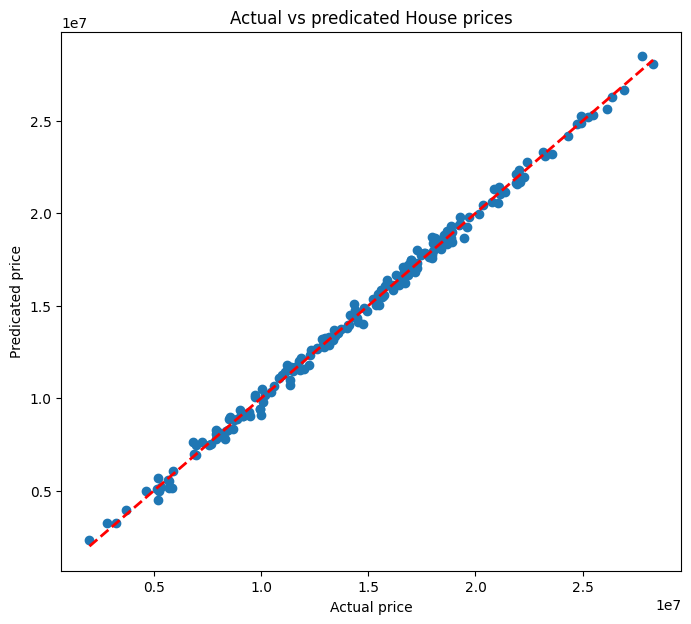

In [33]:
plt.figure(figsize=(8,7))

plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual price")
plt.ylabel("Predicated price")
plt.title("Actual vs predicated House prices")

plt.show()

High Concentration: Most data points are concentrated closely along the main path of the plot (from $0.5 \times 10^7$ to $2.0 \times 10^7$ on both axes).

Strong Alignment: The points are distributed close to the red dashed regression line ($y = x$), indicating that the predicted values are very close to the actual house prices.

Minor Errors: A few points lie slightly farther from the regression line, showing a small degree of prediction error in higher and lower price ranges.

Overall Agreement: Overall, the graph shows strong agreement between the actual and predicted selling prices, confirming high model reliability.

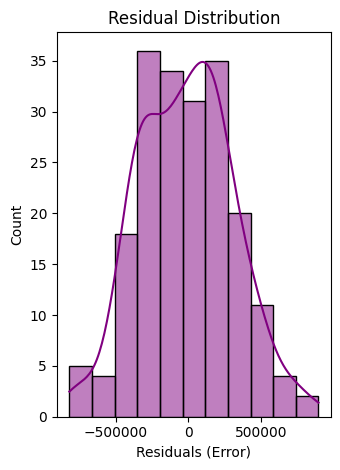

In [34]:
plt.subplot(1,2,2)
residuals=y_test-y_pred
sns.histplot(residuals,kde=True,color='purple')
plt.xlabel('Residuals (Error)')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()

Centered at Zero: The errors (residuals) are concentrated around $0$, showing that the model does not systematically overpredict or underpredict house prices.

Normal Distribution: The purple KDE curve forms a symmetric bell-shaped curve, confirming that the errors are normally distributed.

Error Range: Most residual values fall tightly within $-0.5 \times 10^6$ and $+0.5 \times 10^6$, meaning large prediction errors are rare.

Model Validation: Overall, the residual distribution confirms that the linear model satisfies the core regression assumptions effectively.

# Model Interpretation and Business Insights

In [35]:
feature_names = preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

print(coefficients.head(10))

                  Feature   Coefficient
2          num__Area_sqft  4.634537e+06
0           num__Bedrooms  3.929621e+05
32    cat__Has_Pool_False -2.740919e+05
33     cat__Has_Pool_True  2.740919e+05
1          num__Bathrooms  2.548285e+05
5          num__House_Age -1.854955e+05
10       cat__City_Mumbai  1.599382e+05
31   cat__Has_Garden_True  1.533261e+05
30  cat__Has_Garden_False -1.533261e+05
12       cat__City_Nashik -1.443413e+05


In [36]:
import joblib

joblib.dump(model, "Linear_Regression.joblib")

['Linear_Regression.joblib']

In [37]:
joblib.dump(preprocessor, "preprocessor.joblib")

['preprocessor.joblib']

In [38]:
data.head()

,City,Neighborhood,Property_Type,Bedrooms,Bathrooms,Area_sqft,Lot_Size,Floors,House_Age,Garage_Capacity,Distance_to_City,Crime_Rate,School_Rating,Has_Garden,Has_Pool,Condition,Heating_Type,Target_Column
0,Thane,Thane,Independent House,2,1,1428.0,1849.7,1,14,0,24.0,1.3,2.3,True,True,Poor,Gas,14114722.44
1,Nashik,Nashik,Apartment,1,1,1116.7,1760.2,1,27,1,38.3,4.0,2.3,True,False,Poor,Solar,10167899.87
2,Mumbai,Mumbai,Villa,3,4,2300.1,5200.8,3,18,2,23.5,7.3,2.1,True,False,Fair,Electric,22519584.74
3,Nagpur,Nagpur,Independent House,2,2,1186.5,2418.4,3,13,0,24.8,2.5,4.2,True,False,Good,Solar,11615354.08
4,Nagpur,Nagpur,Independent House,1,1,1115.2,2483.7,2,2,2,3.6,9.2,3.7,False,True,Poor,Gas,11339279.90


In [39]:
new_data = pd.DataFrame([{
    "Bedrooms": int(input("Bedrooms: ")),
    "Bathrooms": int(input("Bathrooms: ")),
    "Area_sqft": float(input("Area sqft: ")),
    "Lot_Size": float(input("Lot Size: ")),
    "Floors": int(input("Floors: ")),
    "House_Age": int(input("House Age: ")),
    "Garage_Capacity": int(input("Garage Capacity: ")),
    "Distance_to_City": float(input("Distance to City: ")),
    "Crime_Rate": float(input("Crime Rate: ")),
    "School_Rating": float(input("School Rating: ")),
    "City": input("City: "),
    "Neighborhood": input("Neighborhood: "),
    "Property_Type": input("Property Type: "),
    "Heating_Type": input("Heating Type: "),
    "Condition": input("Condition: "),
    "Has_Garden":input("Has_Garden "),
    "Has_Pool":input("Has_Pool: ")
}])

new_data = preprocessor.transform(new_data)

prediction = model.predict(new_data)

print("Predicted House Price:", prediction[0])

ValueError: invalid literal for int() with base 10: ''

Area_sqft has the highest coefficient (4.64e+06), indicating that it has the strongest positive impact on property prices. Other important positive features include Bedrooms, Bathrooms, City_Pune, and School_Rating, which are associated with higher predicted prices. Features like House_Age, Crime_Rate, Distance_to_City, Neighborhood_Pune, and City_Nashik have negative coefficients, indicating that they reduce the predicted property price.

Business Insights
House area (Area_sqft) has a significant impact on the selling price. Larger houses generally have higher prices.

Number of bedrooms and bathrooms positively influences the house price. Houses with more rooms are usually more valuable.

House age affects the selling price. Older houses generally have lower prices than newer houses.

Location factors, such as Distance_to_City, Crime_Rate, and School_Rating, have a strong influence on house prices. Houses in safer areas with better schools and closer to the city tend to have higher prices.

Additional amenities such as Garage Capacity, Garden, and Swimming Pool increase the market value of a house.

Property type also impacts the selling price. Villas and independent houses generally have higher prices than apartments.


Conclusion

This project successfully developed a Linear Regression model to predict house prices based on different property features.


The project followed a complete Machine Learning workflow, including data cleaning, exploratory data analysis (EDA), feature engineering, train-test splitting, data preprocessing, model training, prediction, and model evaluation.


The model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.


The results show that the model can predict house prices with good accuracy and demonstrates the practical application of Linear Regression in the real estate domain.



Future Scope
Improve the model by performing hyperparameter tuning and comparing it with advanced regression algorithms.

Use a larger and more recent dataset to improve prediction accuracy.

Add more useful features such as house condition, nearby hospitals, public transport availability, shopping malls, parking facilities, and locality development index.

Deploy the trained model as a web application where users can enter house details and receive an estimated house price instantly.

Integrate the model with real-time real estate data to provide more accurate and up-to-date price predictions.


